# 01 — Join COMED Demand + Weather Data, and EDA

Builds a single clean hourly dataset from the two raw sources in `data/raw/`, following the
cleaning decisions locked in `docs/AmpOps_Project_Context.md` (§2.2, §2.3), then runs EDA on
the result. See also `docs/data_cleaning_plan.md` for what happens to this output *after*
this notebook (lag features, rolling means, DVC versioning) — that's out of scope here.


## 1. Load Data

In [1]:
import re
from pathlib import Path
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
COMED_PATH = RAW_DIR / "COMED_hourly.csv"
WEATHER_PATH = RAW_DIR / "open-meteo-41.86N87.65W179m.csv"

row_counts = {}  # running audit of row counts at every stage (step 3 requirement)


The weather CSV is actually two concatenated Open-Meteo exports — an hourly grain block and,
appended after a second header row, a daily-aggregate re-export of the same period
(`docs/AmpOps_Project_Context.md` §2.2.1). Per the locked decision there, we keep the hourly
grain only. The metadata row at the top of the file (line 1/2) is read separately — it's what
confirms the file is on a **fixed UTC-5 offset with no DST shift**, the fact that drives the
COMED realignment in Section 2 below.


In [2]:
weather_meta = pd.read_csv(WEATHER_PATH, nrows=1)
print("Weather file metadata (confirms fixed UTC-5, no DST):")
weather_meta


Weather file metadata (confirms fixed UTC-5, no DST):


,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation
0,41.862915,-87.64877,179.0,-18000,America/Chicago,GMT-5


In [3]:
# Hourly block only: skip the 3-line metadata preamble, header becomes line 4,
# and nrows=87648 stops before the blank separator + second (daily) header/block.
weather_raw = pd.read_csv(WEATHER_PATH, skiprows=3, nrows=87648)
weather_raw["time"] = pd.to_datetime(weather_raw["time"])
row_counts["weather_hourly_raw"] = len(weather_raw)
print(f"Weather hourly rows loaded: {row_counts['weather_hourly_raw']:,}")
print(f"Range: {weather_raw['time'].min()} -> {weather_raw['time'].max()}")
weather_raw.head()


Weather hourly rows loaded: 87,648
Range: 2010-01-01 00:00:00 -> 2019-12-31 23:00:00


,time,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),precipitation (mm),snow_depth (m),snowfall (cm),rain (mm),weather_code (wmo code),...,wind_direction_100m (°),wind_gusts_10m (km/h),soil_temperature_0_to_7cm (°C),soil_temperature_7_to_28cm (°C),soil_temperature_28_to_100cm (°C),soil_temperature_100_to_255cm (°C),soil_moisture_0_to_7cm (m³/m³),soil_moisture_7_to_28cm (m³/m³),soil_moisture_28_to_100cm (m³/m³),soil_moisture_100_to_255cm (m³/m³)
0,2010-01-01 00:00:00,-8.6,68,-13.4,-14.8,0.0,0.08,0.0,0.0,2,...,299,33.8,-0.2,0.0,1.5,5.5,0.173,0.177,0.198,0.193
1,2010-01-01 01:00:00,-8.9,70,-13.3,-15.3,0.0,0.08,0.0,0.0,2,...,294,32.4,-0.2,0.1,1.5,5.5,0.173,0.177,0.198,0.193
2,2010-01-01 02:00:00,-9.2,75,-12.8,-15.5,0.0,0.08,0.0,0.0,1,...,294,34.2,-0.3,0.1,1.5,5.5,0.173,0.177,0.198,0.193
3,2010-01-01 03:00:00,-9.5,77,-12.8,-15.8,0.0,0.08,0.0,0.0,0,...,295,33.1,-0.3,0.1,1.5,5.5,0.173,0.177,0.198,0.193
4,2010-01-01 04:00:00,-9.8,78,-12.9,-16.0,0.0,0.08,0.0,0.0,0,...,295,31.3,-0.3,0.1,1.5,5.5,0.173,0.176,0.198,0.193


In [4]:
comed_raw = pd.read_csv(COMED_PATH, parse_dates=["Datetime"])
row_counts["comed_raw"] = len(comed_raw)
print(f"COMED raw rows loaded: {row_counts['comed_raw']:,}")
print(f"Columns: {list(comed_raw.columns)}")
comed_raw.head()


COMED raw rows loaded: 66,497
Columns: ['Datetime', 'COMED_MW']


,Datetime,COMED_MW
0,2011-12-31 01:00:00,9970.0
1,2011-12-31 02:00:00,9428.0
2,2011-12-31 03:00:00,9059.0
3,2011-12-31 04:00:00,8817.0
4,2011-12-31 05:00:00,8743.0


## 2. Clean & Realign COMED

Per `docs/AmpOps_Project_Context.md` §2.2.2 and §2.3:

- `COMED_hourly.csv`'s raw file is **not stored in chronological order** (it's grouped into
  per-day blocks that run in descending date order within each year) — any time-series
  operation needs an explicit sort first.
- 4 timestamps are duplicated at DST fall-back hours, each with two different `COMED_MW`
  readings — the locked decision is to **average** the two readings rather than keep-first.
- COMED's `Datetime` is local Chicago clock time that observes real DST transitions, while the
  weather file is fixed UTC-5. The locked fix is to convert COMED onto that same fixed-UTC-5
  grid before joining, validated afterward with an hour-of-day sanity check (Section 4).


In [5]:
# Sort chronologically — required, see note above.
comed_sorted = comed_raw.sort_values("Datetime").reset_index(drop=True)
row_counts["comed_sorted"] = len(comed_sorted)
assert row_counts["comed_sorted"] == row_counts["comed_raw"], "sort should not change row count"
print(f"COMED rows after chronological sort: {row_counts['comed_sorted']:,}")


COMED rows after chronological sort: 66,497


In [6]:
# Average the 4 duplicated fall-back-hour timestamps (§2.3 decision).
dup_counts = comed_sorted["Datetime"].value_counts()
duplicated_timestamps = dup_counts[dup_counts > 1]
print(f"Duplicated timestamps found: {len(duplicated_timestamps)}")
display(duplicated_timestamps.sort_index())

comed_deduped = comed_sorted.groupby("Datetime", as_index=False)["COMED_MW"].mean()
row_counts["comed_deduped"] = len(comed_deduped)
print(
    f"COMED rows after averaging duplicate fall-back hours: {row_counts['comed_deduped']:,} "
    f"(dropped {row_counts['comed_sorted'] - row_counts['comed_deduped']})"
)


Duplicated timestamps found: 4


Datetime
2014-11-02 02:00:00    2
2015-11-01 02:00:00    2
2016-11-06 02:00:00    2
2017-11-05 02:00:00    2
Name: count, dtype: int64

COMED rows after averaging duplicate fall-back hours: 66,493 (dropped 4)


In [7]:
# DST realignment onto the weather file's fixed-UTC-5 grid.
#
# For each *row* (not each date — the offset must be resolved per timestamp, since on the two
# transition days themselves the correct offset changes partway through the day), look up the
# real America/Chicago UTC offset for that exact naive timestamp. Python's `zoneinfo` is
# fold-aware (PEP 495) and never raises on the ambiguous/nonexistent clock hours right at a
# transition — it resolves them deterministically (fold=0, the default) — which is what makes
# a per-row lookup safe here.  CST rows (offset -6h) need +1h to land on the weather file's
# fixed UTC-5 grid; CDT rows (offset -5h) are already aligned.
#
# An earlier per-*date* version of this (flagging is_dst once per calendar day, e.g. via noon)
# introduced 8 spurious duplicate timestamps: on the two transition days, hours before the
# actual transition instant still need the *previous* offset, which a whole-day flag gets
# wrong. Per-row lookup fixes that — verified below via the duplicate-count assertion.
CHICAGO = ZoneInfo("America/Chicago")


def utc_offset_hours(ts: pd.Timestamp) -> float:
    return ts.to_pydatetime().replace(tzinfo=CHICAGO).utcoffset().total_seconds() / 3600


comed_deduped = comed_deduped.copy()
comed_deduped["utc_offset_hours"] = comed_deduped["Datetime"].map(utc_offset_hours)
comed_deduped["shift_hours"] = (-5 - comed_deduped["utc_offset_hours"]).astype(int)
comed_deduped["Datetime_fixed_utc5"] = comed_deduped["Datetime"] + pd.to_timedelta(
    comed_deduped["shift_hours"], unit="h"
)

n_new_dupes = int(comed_deduped["Datetime_fixed_utc5"].duplicated().sum())
assert n_new_dupes == 0, f"DST realignment introduced {n_new_dupes} new duplicate timestamps"
print("No new duplicate timestamps introduced by the DST shift.")

comed_clean = (
    comed_deduped[["Datetime_fixed_utc5", "COMED_MW"]]
    .rename(columns={"Datetime_fixed_utc5": "time"})
    .sort_values("time")
    .reset_index(drop=True)
)
row_counts["comed_dst_realigned"] = len(comed_clean)
print(f"COMED rows after DST realignment: {row_counts['comed_dst_realigned']:,}")
comed_clean.head()


No new duplicate timestamps introduced by the DST shift.
COMED rows after DST realignment: 66,493


,time,COMED_MW
0,2011-01-01 02:00:00,9631.0
1,2011-01-01 03:00:00,9273.0
2,2011-01-01 04:00:00,9011.0
3,2011-01-01 05:00:00,8741.0
4,2011-01-01 06:00:00,8694.0


## 3. Trim & Join

Trim both sources to the confirmed overlap window (`docs/AmpOps_Project_Context.md` §2.3):
**2011-01-01 through 2018-08-03**, COMED's own range. Weather column names are cleaned up
(units stripped out of the header labels) before the join for readability.


In [8]:
# Exact confirmed COMED range (docs/AmpOps_Project_Context.md §2.1/§2.3) — not padded to
# end-of-day, since that's the literal bound COMED's raw data reaches.
WINDOW_START = pd.Timestamp("2011-01-01 01:00:00")
WINDOW_END = pd.Timestamp("2018-08-03 00:00:00")

weather_trimmed = weather_raw[
    (weather_raw["time"] >= WINDOW_START) & (weather_raw["time"] <= WINDOW_END)
].reset_index(drop=True)
comed_trimmed = comed_clean[
    (comed_clean["time"] >= WINDOW_START) & (comed_clean["time"] <= WINDOW_END)
].reset_index(drop=True)

row_counts["weather_trimmed"] = len(weather_trimmed)
row_counts["comed_trimmed"] = len(comed_trimmed)
print(f"Weather rows after trim to overlap window: {row_counts['weather_trimmed']:,}")
print(f"COMED rows after trim to overlap window: {row_counts['comed_trimmed']:,}")


Weather rows after trim to overlap window: 66,504
COMED rows after trim to overlap window: 66,493


In [9]:
def clean_col(c: str) -> str:
    c = re.sub(r"\s*\(.*?\)", "", c)  # strip parenthetical units, e.g. "(°C)"
    return c.strip().lower().replace(" ", "_")


weather_trimmed = weather_trimmed.rename(
    columns={c: clean_col(c) for c in weather_trimmed.columns if c != "time"}
)
weather_trimmed.columns.tolist()


['time',
 'temperature_2m',
 'relative_humidity_2m',
 'dew_point_2m',
 'apparent_temperature',
 'precipitation',
 'snow_depth',
 'snowfall',
 'rain',
 'weather_code',
 'pressure_msl',
 'surface_pressure',
 'cloud_cover',
 'cloud_cover_low',
 'cloud_cover_mid',
 'cloud_cover_high',
 'et0_fao_evapotranspiration',
 'vapour_pressure_deficit',
 'wind_speed_10m',
 'wind_speed_100m',
 'wind_direction_10m',
 'wind_direction_100m',
 'wind_gusts_10m',
 'soil_temperature_0_to_7cm',
 'soil_temperature_7_to_28cm',
 'soil_temperature_28_to_100cm',
 'soil_temperature_100_to_255cm',
 'soil_moisture_0_to_7cm',
 'soil_moisture_7_to_28cm',
 'soil_moisture_28_to_100cm',
 'soil_moisture_100_to_255cm']

In [10]:
joined = pd.merge(comed_trimmed, weather_trimmed, on="time", how="inner")
row_counts["joined"] = len(joined)
print(f"Joined dataset rows: {row_counts['joined']:,}, columns: {joined.shape[1]}")
joined.head()


Joined dataset rows: 66,493, columns: 32


,time,COMED_MW,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,snow_depth,snowfall,rain,...,wind_direction_100m,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm
0,2011-01-01 02:00:00,9631.0,6.9,98,6.6,2.6,0.2,0.0,0.0,0.2,...,260,41.4,3.8,2.5,1.6,5.7,0.219,0.221,0.186,0.173
1,2011-01-01 03:00:00,9273.0,3.3,90,1.7,-2.1,0.0,0.0,0.0,0.0,...,264,42.5,3.0,2.6,1.6,5.7,0.217,0.220,0.187,0.173
2,2011-01-01 04:00:00,9011.0,0.9,76,-2.9,-5.2,0.0,0.0,0.0,0.0,...,254,42.1,2.2,2.5,1.6,5.7,0.214,0.219,0.187,0.173
3,2011-01-01 05:00:00,8741.0,-0.6,70,-5.4,-6.3,0.0,0.0,0.0,0.0,...,255,42.1,1.3,2.4,1.6,5.7,0.212,0.218,0.188,0.173
4,2011-01-01 06:00:00,8694.0,-2.0,68,-7.0,-7.5,0.0,0.0,0.0,0.0,...,248,40.0,0.6,2.2,1.6,5.7,0.210,0.217,0.188,0.173


## 4. DST Realignment Sanity Check

Directly tests the realignment logic itself: build a second, **naive** join that skips the
DST correction entirely (COMED's raw local `Datetime` matched straight against weather's fixed
UTC-5 `time`). Since only Standard-Time (winter, CST) rows get the +1h correction, the
**winter** hourly profile should shift by ~1 hour between the naive and realigned joins, while
the **summer** (CDT) profile — already on a fixed UTC-5 grid pre-correction — should barely
change. That's a falsifiable check on the mechanism, not just a plausibility read.


Naive (no DST correction) join rows: 66,493


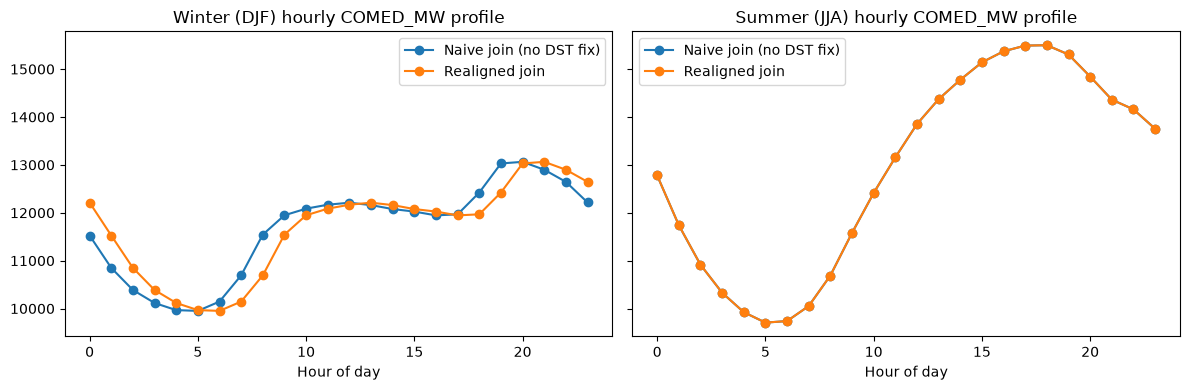

In [11]:
naive_join = pd.merge(
    comed_deduped[["Datetime", "COMED_MW"]].rename(columns={"Datetime": "time"}),
    weather_trimmed,
    on="time",
    how="inner",
)
print(f"Naive (no DST correction) join rows: {len(naive_join):,}")


def hourly_profile(df, months, col="COMED_MW"):
    sub = df[df["time"].dt.month.isin(months)]
    return sub.assign(hour=sub["time"].dt.hour).groupby("hour")[col].mean()


WINTER, SUMMER = [12, 1, 2], [6, 7, 8]

naive_winter, realigned_winter = hourly_profile(naive_join, WINTER), hourly_profile(joined, WINTER)
naive_summer, realigned_summer = hourly_profile(naive_join, SUMMER), hourly_profile(joined, SUMMER)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
naive_winter.plot(ax=axes[0], marker="o", label="Naive join (no DST fix)")
realigned_winter.plot(ax=axes[0], marker="o", label="Realigned join")
axes[0].set_title("Winter (DJF) hourly COMED_MW profile")
axes[0].set_xlabel("Hour of day"); axes[0].legend()

naive_summer.plot(ax=axes[1], marker="o", label="Naive join (no DST fix)")
realigned_summer.plot(ax=axes[1], marker="o", label="Realigned join")
axes[1].set_title("Summer (JJA) hourly COMED_MW profile")
axes[1].set_xlabel("Hour of day"); axes[1].legend()
plt.tight_layout()
plt.show()


In [12]:
# Numeric check: realigned winter profile should correlate more strongly with the naive
# winter profile shifted by +1h than with the naive profile unshifted.
unshifted_corr = np.corrcoef(realigned_winter.values, naive_winter.values)[0, 1]
shifted_corr = np.corrcoef(realigned_winter.values, np.roll(naive_winter.values, 1))[0, 1]
summer_corr = np.corrcoef(realigned_summer.values, naive_summer.values)[0, 1]

print(f"Winter: naive vs realigned, unshifted correlation  = {unshifted_corr:.3f}")
print(f"Winter: naive vs realigned, naive rolled +1h        = {shifted_corr:.3f}  (expect higher)")
print(f"Summer: naive vs realigned, unshifted correlation   = {summer_corr:.3f}  (expect ~1.0, no shift needed)")

assert shifted_corr > unshifted_corr, "DST realignment does not show the expected winter 1h shift"
assert summer_corr > 0.99, "Summer profile changed even though no DST correction should apply"
print("\nSanity check passed: realignment shifts winter (CST) rows by 1h and leaves summer (CDT) rows untouched.")


Winter: naive vs realigned, unshifted correlation  = 0.925
Winter: naive vs realigned, naive rolled +1h        = 1.000  (expect higher)
Summer: naive vs realigned, unshifted correlation   = 1.000  (expect ~1.0, no shift needed)

Sanity check passed: realignment shifts winter (CST) rows by 1h and leaves summer (CDT) rows untouched.


## 5. Row Count Summary

In [13]:
summary = pd.Series(row_counts, name="rows").to_frame()
summary["delta_vs_previous"] = summary["rows"].diff().fillna(0).astype(int)
summary


,rows,delta_vs_previous
weather_hourly_raw,87648,0
comed_raw,66497,-21151
comed_sorted,66497,0
comed_deduped,66493,-4
comed_dst_realigned,66493,0
weather_trimmed,66504,11
comed_trimmed,66493,-11
joined,66493,0


## 6. Exploratory Data Analysis

### 6.1 Schema, dtypes, nulls, duplicates

In [14]:
joined.info()


<class 'pandas.DataFrame'>
RangeIndex: 66493 entries, 0 to 66492
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   time                           66493 non-null  datetime64[us]
 1   COMED_MW                       66493 non-null  float64       
 2   temperature_2m                 66493 non-null  float64       
 3   relative_humidity_2m           66493 non-null  int64         
 4   dew_point_2m                   66493 non-null  float64       
 5   apparent_temperature           66493 non-null  float64       
 6   precipitation                  66493 non-null  float64       
 7   snow_depth                     66493 non-null  float64       
 8   snowfall                       66493 non-null  float64       
 9   rain                           66493 non-null  float64       
 10  weather_code                   66493 non-null  int64         
 11  pressure_msl              

In [15]:
print("Null counts:")
display(joined.isna().sum())
print(f"\nFully duplicated rows: {joined.duplicated().sum()}")
print(f"Duplicated timestamps: {joined.duplicated(subset='time').sum()}")


Null counts:


time                             0
COMED_MW                         0
temperature_2m                   0
relative_humidity_2m             0
dew_point_2m                     0
apparent_temperature             0
precipitation                    0
snow_depth                       0
snowfall                         0
rain                             0
weather_code                     0
pressure_msl                     0
surface_pressure                 0
cloud_cover                      0
cloud_cover_low                  0
cloud_cover_mid                  0
cloud_cover_high                 0
et0_fao_evapotranspiration       0
vapour_pressure_deficit          0
wind_speed_10m                   0
wind_speed_100m                  0
wind_direction_10m               0
wind_direction_100m              0
wind_gusts_10m                   0
soil_temperature_0_to_7cm        0
soil_temperature_7_to_28cm       0
soil_temperature_28_to_100cm     0
soil_temperature_100_to_255cm    0
soil_moisture_0_to_7


Fully duplicated rows: 0
Duplicated timestamps: 0


### 6.2 COMED_MW distribution & trend

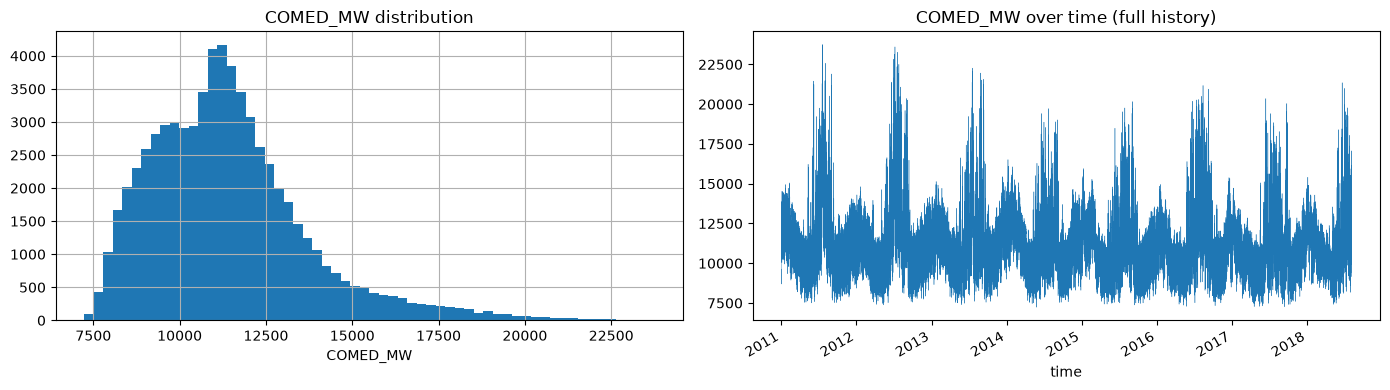

count    66493.000000
mean     11420.341585
std       2304.076173
min       7237.000000
25%       9781.000000
50%      11152.000000
75%      12510.000000
max      23753.000000
Name: COMED_MW, dtype: float64

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
joined["COMED_MW"].hist(bins=60, ax=axes[0])
axes[0].set_title("COMED_MW distribution")
axes[0].set_xlabel("COMED_MW")

joined.set_index("time")["COMED_MW"].plot(ax=axes[1], linewidth=0.3)
axes[1].set_title("COMED_MW over time (full history)")
plt.tight_layout()
plt.show()

joined["COMED_MW"].describe()


### 6.3 Seasonality — hour-of-day, day-of-week, month-of-year

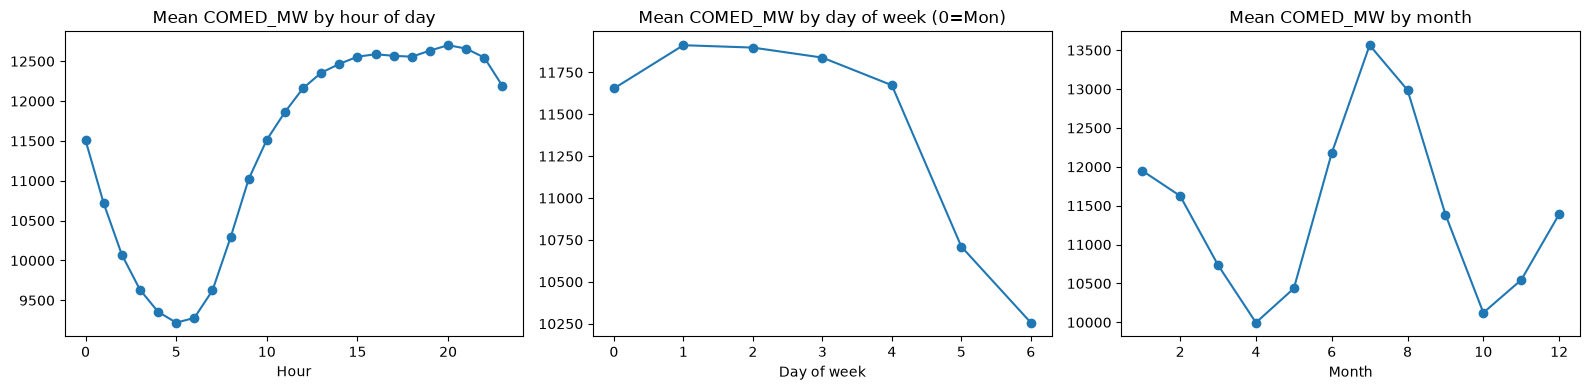

In [17]:
seasonal = joined.assign(
    hour=joined["time"].dt.hour,
    dow=joined["time"].dt.dayofweek,
    month=joined["time"].dt.month,
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
seasonal.groupby("hour")["COMED_MW"].mean().plot(ax=axes[0], marker="o")
axes[0].set_title("Mean COMED_MW by hour of day")
axes[0].set_xlabel("Hour")

seasonal.groupby("dow")["COMED_MW"].mean().plot(ax=axes[1], marker="o")
axes[1].set_title("Mean COMED_MW by day of week (0=Mon)")
axes[1].set_xlabel("Day of week")

seasonal.groupby("month")["COMED_MW"].mean().plot(ax=axes[2], marker="o")
axes[2].set_title("Mean COMED_MW by month")
axes[2].set_xlabel("Month")
plt.tight_layout()
plt.show()


### 6.4 Outlier check on COMED_MW

IQR bounds (3x IQR fence): [1594, 20697] MW
Outlier rows: 224 (0.34% of joined dataset)


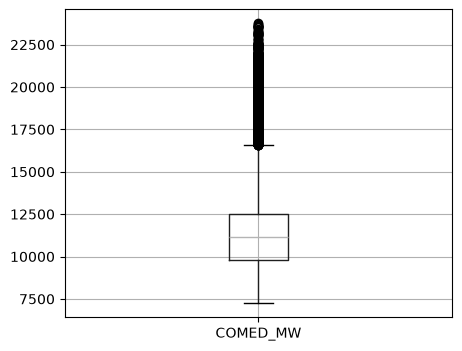

,time,COMED_MW,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,snow_depth,snowfall,rain,...,wind_direction_100m,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm
4816,2011-07-20 18:00:00,23753.0,35.3,55,24.7,38.9,0.0,0.0,0.0,0.0,...,229,36.4,36.4,32.2,27.8,23.2,0.072,0.125,0.159,0.190
4815,2011-07-20 17:00:00,23713.0,35.4,55,25.0,39.3,0.0,0.0,0.0,0.0,...,227,38.2,37.3,32.1,27.8,23.2,0.073,0.125,0.159,0.190
4839,2011-07-21 17:00:00,23670.0,33.6,61,25.0,39.9,0.0,0.0,0.0,0.0,...,239,20.9,38.4,32.6,27.9,23.2,0.066,0.122,0.157,0.190
13261,2012-07-06 17:00:00,23603.0,34.8,58,25.2,41.0,0.0,0.0,0.0,0.0,...,246,15.1,43.3,34.7,29.1,23.9,0.045,0.086,0.123,0.175
4838,2011-07-21 16:00:00,23587.0,33.6,60,24.8,40.0,0.0,0.0,0.0,0.0,...,286,23.8,38.5,32.3,27.9,23.1,0.067,0.123,0.157,0.190
4817,2011-07-20 19:00:00,23582.0,34.8,56,24.7,38.7,0.0,0.0,0.0,0.0,...,229,36.0,35.2,32.1,27.6,23.1,0.072,0.125,0.159,0.190
4840,2011-07-21 18:00:00,23542.0,33.6,62,25.3,39.8,0.0,0.0,0.0,0.0,...,266,20.5,37.7,32.7,28.0,23.2,0.066,0.122,0.157,0.190
13260,2012-07-06 16:00:00,23533.0,34.9,56,24.9,42.5,0.0,0.0,0.0,0.0,...,270,16.6,44.1,34.4,29.0,23.9,0.046,0.086,0.123,0.175
4814,2011-07-20 16:00:00,23524.0,35.1,57,25.2,39.7,0.0,0.0,0.0,0.0,...,231,36.4,37.8,31.9,27.7,23.2,0.073,0.126,0.159,0.190
13262,2012-07-06 18:00:00,23516.0,34.5,60,25.6,40.5,0.0,0.0,0.0,0.0,...,260,16.2,41.8,34.8,29.1,23.9,0.045,0.085,0.123,0.175


In [18]:
q1, q3 = joined["COMED_MW"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 3 * iqr, q3 + 3 * iqr
outliers = joined[(joined["COMED_MW"] < lower) | (joined["COMED_MW"] > upper)]

print(f"IQR bounds (3x IQR fence): [{lower:.0f}, {upper:.0f}] MW")
print(f"Outlier rows: {len(outliers):,} ({len(outliers) / len(joined):.2%} of joined dataset)")

fig, ax = plt.subplots(figsize=(5, 4))
joined.boxplot(column="COMED_MW", ax=ax)
plt.show()

outliers.sort_values("COMED_MW", ascending=False).head(10)


### 6.5 Correlation with weather variables

In [19]:
weather_cols = [c for c in weather_trimmed.columns if c != "time"]
corr = (
    joined[["COMED_MW"] + weather_cols]
    .corr()["COMED_MW"]
    .drop("COMED_MW")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
corr.to_frame("corr_with_COMED_MW")


,corr_with_COMED_MW
vapour_pressure_deficit,0.489571
et0_fao_evapotranspiration,0.410886
soil_temperature_0_to_7cm,0.356330
apparent_temperature,0.290445
soil_temperature_7_to_28cm,0.286926
temperature_2m,0.266044
soil_moisture_0_to_7cm,-0.260813
soil_temperature_28_to_100cm,0.251722
relative_humidity_2m,-0.238372
soil_temperature_100_to_255cm,0.232272


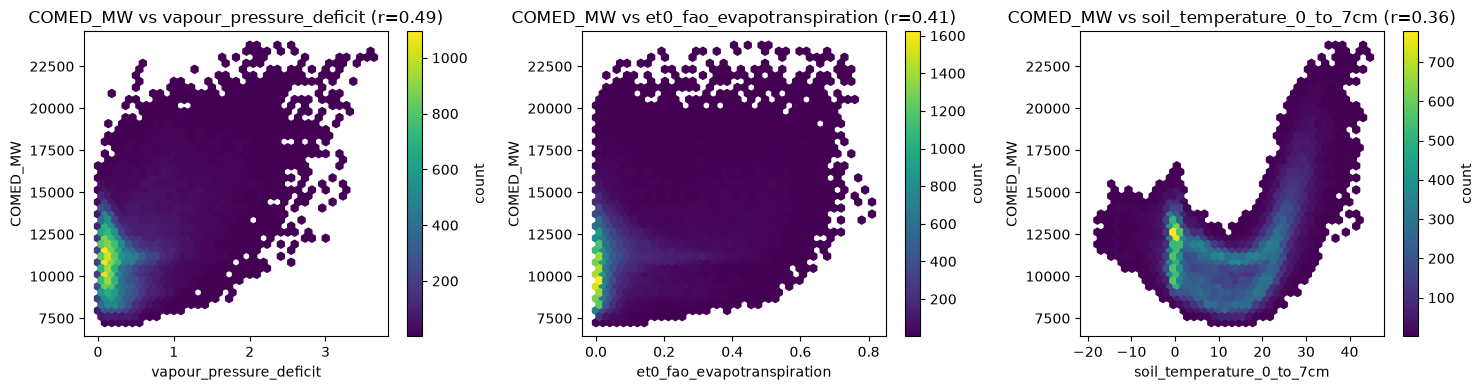

In [20]:
top_features = corr.abs().sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(1, len(top_features), figsize=(5 * len(top_features), 4))
if len(top_features) == 1:
    axes = [axes]
for ax, col in zip(axes, top_features):
    hb = ax.hexbin(joined[col], joined["COMED_MW"], gridsize=40, cmap="viridis", mincnt=1)
    ax.set_xlabel(col)
    ax.set_ylabel("COMED_MW")
    ax.set_title(f"COMED_MW vs {col} (r={corr[col]:.2f})")
    fig.colorbar(hb, ax=ax, label="count")
plt.tight_layout()
plt.show()


### 6.6 Residual gap analysis

In [21]:
full_range = pd.date_range(WINDOW_START, WINDOW_END, freq="h")
present = pd.DatetimeIndex(joined["time"].unique())
missing_timestamps = full_range.difference(present)

print(f"Expected hourly timestamps in overlap window: {len(full_range):,}")
print(f"Present in joined dataset: {len(present):,}")
print(f"Missing timestamps: {len(missing_timestamps):,}")

missing_df = pd.DataFrame({"missing_time": missing_timestamps})
if len(missing_df):
    missing_df["month"] = missing_df["missing_time"].dt.to_period("M")
    display(missing_df.groupby("month").size().rename("missing_hours"))
    display(missing_df)
else:
    print("No missing timestamps in the overlap window.")


Expected hourly timestamps in overlap window: 66,504
Present in joined dataset: 66,493
Missing timestamps: 11


month
2011-01    1
2011-11    2
2012-11    2
2013-11    2
2014-11    1
2015-11    1
2016-11    1
2017-11    1
Freq: M, Name: missing_hours, dtype: int64

,missing_time,month
0,2011-01-01 01:00:00,2011-01
1,2011-11-06 02:00:00,2011-11
2,2011-11-06 03:00:00,2011-11
3,2012-11-04 02:00:00,2012-11
4,2012-11-04 03:00:00,2012-11
5,2013-11-03 02:00:00,2013-11
6,2013-11-03 03:00:00,2013-11
7,2014-11-02 02:00:00,2014-11
8,2015-11-01 02:00:00,2015-11
9,2016-11-06 02:00:00,2016-11


**Where the remaining gaps actually come from** (worth spelling out, since it's not what you'd
guess going in): the 11 spring-forward hours flagged in `docs/AmpOps_Project_Context.md` §2.2.2
turn out to be a property of the *raw* file only — once every row is shifted per-timestamp onto
the fixed-UTC-5 grid (Section 2), the spring-forward side re-fills itself, because the row the
raw file happens to label as the transition-day's ambiguous extra hour lands exactly in the
fixed-grid slot that would otherwise be empty. The residual gaps seen above instead come from
**fall-back events**: in years where the raw file had no duplicate reading at all for that hour
(2011–2013 — recall §2.2.2's "inconsistent year to year"), realigning leaves **2** fixed-grid
hours short, since one real reading can't cover two real hours; in years where a duplicate *was*
present and got averaged per the §2.3 decision (2014–2017), it leaves only **1** hour short,
since averaging two real readings into one still only fills one fixed-grid slot. The one
remaining gap (`2011-01-01 01:00`) is a window-start boundary edge effect of the shift itself.
`docs/data_cleaning_plan.md` (§2, residual-gap handling) flags how to treat these (fill vs.
leave as NaN) as an open question for the downstream feature-engineering step, not resolved
here.


## 7. Save Cleaned Dataset

In [22]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
out_path = PROCESSED_DIR / "joined_hourly.parquet"
joined.to_parquet(out_path, index=False)
print(f"Saved {len(joined):,} rows x {joined.shape[1]} columns to {out_path}")


Saved 66,493 rows x 32 columns to ../data/processed/joined_hourly.parquet
